# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [1]:
# Restart the Kernel after you execute this command.

!python -m pip install -r requirements.txt

e:\VCS\udacity\udacity-mnist-classification\.venv\Scripts\python.exe: No module named pip


**Important: Restart the Kernel at this moment**

## Imports

In [2]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [3]:
from mnist.data import get_notebook_loaders
from mnist.models import get_model
from mnist.train import get_device, train_model
from mnist.evaluate import evaluate_model
from mnist.analysis import confusion_matrix, per_class_report
from mnist.save import load_all_results

print(f"Note: I have done experimentation outside of this notebook, so I will be using the winning configuration in this notebook.")
train_loader, test_loader = get_notebook_loaders(batch_size=128, augmentation="affine")

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Note: I have done experimentation outside of this notebook, so I will be using the winning configuration in this notebook.
Train batches: 469
Test batches:  79


## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

As stated in the readme of this project, I have already done quite some experiments before arriving at the notebook. I wanted to explore the dataset, and try different setups. For the transforms I am using, the `toTensor()`function is used to convert the image from height, width and channel layout into a tensor. This is what PyTorch expects. Transforming into 0-1 values avoids gradient scaling issues we may get in 0-255 values. WIth this I mean gradients exploding or impoding after the first layer. I normalized by using the mean and divide by standard deviation. This is done to bring all inputs ointo the same scale, which allow for gradients to work well. I picked the `affine` augmentation as it was part of the winning configuration. Adding rotation to the images would make the model have to interalize how to recognize numbers in a generic fashion, rather than decise on specific sectors.

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [4]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

Train dataset: 60000 samples
Test dataset:  10000 samples
Batch shape: torch.Size([128, 1, 28, 28]), dtype: torch.float32
Label shape: (128,), dtype: torch.int64
Pixel min: -0.4242, max: 2.8215, mean: 0.0085, std: 1.0088
9


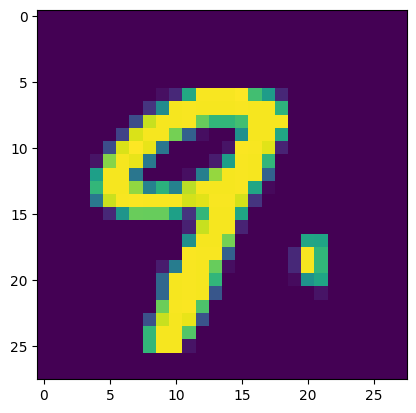

4


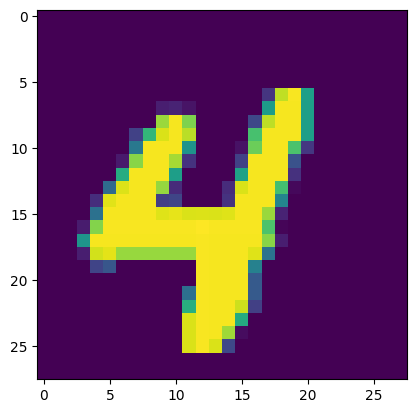

3


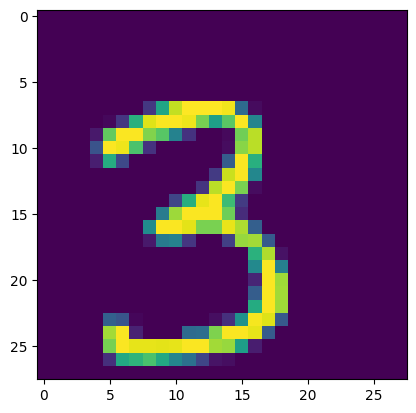

4


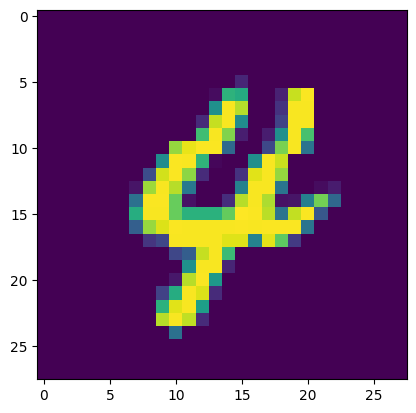

8


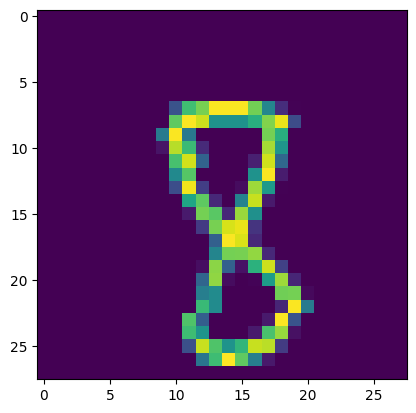

In [7]:
# Dataset sizes
print(f"Train dataset: {len(train_loader.dataset)} samples")
print(f"Test dataset:  {len(test_loader.dataset)} samples")

# Shape and type of a single batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, dtype: {images.dtype}")
print(f"Label shape: {tuple(labels.shape)}, dtype: {labels.dtype}")

# Pixel range after normalization, expected to be near-zero mean and unit variance
print(f"Pixel min: {images.min().item():.4f}, max: {images.max().item():.4f}, mean: {images.mean().item():.4f}, std: {images.std().item():.4f}")

show5(train_loader)


## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [9]:
model = get_model("resnet_small", base_channels=32, dropout=0.3)
parameter_count = sum(p.numel() for p in model.parameters())
print(f"Model architecture: {model}")
print(f"Total parameters: {parameter_count}")


Model architecture: SmallResNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [10]:
criterion = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
print(f"Note: I have done experimentation outside of this notebook, so I will be using the winning configuration in this notebook. AdamW over Adam due to better generalization, and a cosine annealing learning rate scheduler to help convergence.")
print(f"For further details, check the README.md")
device = get_device()
print(f"Using device: {device}")
model = model.to(device)

Note: I have done experimentation outside of this notebook, so I will be using the winning configuration in this notebook. AdamW over Adam due to better generalization, and a cosine annealing learning rate scheduler to help convergence.
For further details, check the README.md
  Using GPU: NVIDIA GeForce RTX 4060 Ti
  CUDA Version: 12.4
  PyTorch Version: 2.6.0+cu124
  GPU Memory: 16.0 GB
Using device: cuda


## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [19]:
history = train_model(
    model, 
    train_loader=train_loader, 
    epochs=15, 
    optimizer=optimizer, 
    scheduler=scheduler, 
    device=device,
    label_smoothing=0.1
)

  Epoch 1/15 — train_loss: 0.8861, train_acc: 0.9808, val_loss: nan, val_acc: nan, lr: 4.32e-05, time: 19.1s
  Epoch 2/15 — train_loss: 0.6357, train_acc: 0.9889, val_loss: nan, val_acc: nan, lr: 9.55e-05, time: 25.0s
  Epoch 3/15 — train_loss: 0.5866, train_acc: 0.9943, val_loss: nan, val_acc: nan, lr: 1.65e-04, time: 23.1s
  Epoch 4/15 — train_loss: 0.5600, train_acc: 0.9961, val_loss: nan, val_acc: nan, lr: 2.50e-04, time: 20.8s
  Epoch 5/15 — train_loss: 0.5440, train_acc: 0.9967, val_loss: nan, val_acc: nan, lr: 3.45e-04, time: 20.0s
  Epoch 6/15 — train_loss: 0.5360, train_acc: 0.9966, val_loss: nan, val_acc: nan, lr: 4.48e-04, time: 21.4s
  Epoch 7/15 — train_loss: 0.5330, train_acc: 0.9960, val_loss: nan, val_acc: nan, lr: 5.52e-04, time: 21.6s
  Epoch 8/15 — train_loss: 0.5316, train_acc: 0.9959, val_loss: nan, val_acc: nan, lr: 6.55e-04, time: 27.0s
  Epoch 9/15 — train_loss: 0.5316, train_acc: 0.9954, val_loss: nan, val_acc: nan, lr: 7.50e-04, time: 18.3s
  Epoch 10/15 — tra

Plot the training loss (and validation loss/accuracy, if recorded).

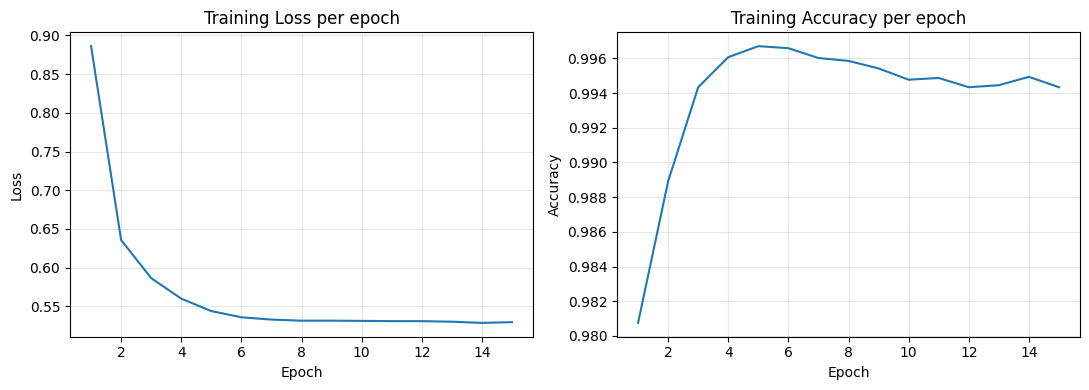

In [20]:
epochs = range(1, len(history.train_loss) + 1)
fix, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs, history.train_loss, label="Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss per epoch")
ax[0].grid(True, alpha=0.3)

ax[1].plot(epochs, history.train_acc, label="Training Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training Accuracy per epoch")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [21]:
results = evaluate_model(model, test_loader, device)
print(f"Test Loss: {results["loss"]:.4f}")
print(f"Test Accuracy: {results["overall_accuracy"]:.4f}")

print("Per-class report:")
for digit, accuracy in results["per_class_accuracy"].items():
    print(f"Digit {digit}: Accuracy {accuracy:.4f}")

matrix = confusion_matrix(results["predictions"], results["ground_truth"])
report = per_class_report(results["predictions"], results["ground_truth"])

print("Confusion Matrix:")
print(matrix)

print("\nPer-class Report:")
for digit, metrics in report.items():
    print(f"Digit {digit}: Precision {metrics["precision"]:.4f}, Recall {metrics["recall"]:.4f}, F1-score {metrics["f1"]:.4f}")

Test Loss: 0.1048
Test Accuracy: 99.4300
Per-class report:
Digit 0: Accuracy 99.5918
Digit 1: Accuracy 99.7357
Digit 2: Accuracy 99.3217
Digit 3: Accuracy 99.8020
Digit 4: Accuracy 99.5927
Digit 5: Accuracy 99.1031
Digit 6: Accuracy 99.5825
Digit 7: Accuracy 98.8327
Digit 8: Accuracy 99.4867
Digit 9: Accuracy 99.2071
Confusion Matrix:
[[ 976    0    0    0    0    0    2    1    1    0]
 [   0 1132    0    1    0    2    0    0    0    0]
 [   0    2 1025    0    0    0    0    4    1    0]
 [   0    0    0 1008    0    2    0    0    0    0]
 [   0    0    0    0  978    0    0    0    0    4]
 [   0    0    0    6    0  884    1    1    0    0]
 [   0    2    0    0    0    1  954    0    1    0]
 [   0   10    1    0    1    0    0 1016    0    0]
 [   0    0    3    0    0    1    0    0  969    1]
 [   0    2    0    0    3    0    0    2    1 1001]]

Per-class Report:
Digit 0: Precision 1.0000, Recall 0.9959, F1-score 0.9980
Digit 1: Precision 0.9861, Recall 0.9974, F1-score 0.99

## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [22]:
print(f"Note: The tuning step happened outside of this notebook, so I will be loading the results from the tuning step to show the best configuration's performance in this notebook.")
sweep_results = load_all_results("results")


rows = []
for run_name, payload in sweep_results.items():
    evaluation = payload.get("evaluation", {})
    config = payload.get("config", {})
    rows.append({
        "run_name": run_name,
        "test_acc": evaluation.get("overall_accuracy", float("nan")),
        "model": config.get("model", {}).get("name", "unknown"),
        "augmentation": config.get("data", {}).get("augmentation", "unknown"),
        "optimizer": config.get("optimizer", {}).get("name", "unknown"),
        "scheduler": config.get("scheduler", {}).get("name", "unknown"),
    })

rows.sort(key=lambda row: row["test_acc"], reverse=True)

print(f"Top 5 configurations:")
for row in rows[:5]:
    print(f"Run: {row['run_name']}, Test Accuracy: {row['test_acc']:.4f}, Model: {row['model']}, Augmentation: {row['augmentation']}, Optimizer: {row['optimizer']}, Scheduler: {row['scheduler']}")  

Note: The tuning step happened outside of this notebook, so I will be loading the results from the tuning step to show the best configuration's performance in this notebook.
Top 5 configurations:
Run: resnet_small_affine_adamw_cosine_do0p3-wd0p0005-ls0p1, Test Accuracy: 99.7200, Model: resnet_small, Augmentation: affine, Optimizer: adamw, Scheduler: cosine
Run: resnet_small_affine_adamw_cosine_do0p2, Test Accuracy: 99.7000, Model: resnet_small, Augmentation: affine, Optimizer: adamw, Scheduler: cosine
Run: deeper_cnn_affine_adamw_cosine_do0p2, Test Accuracy: 99.6700, Model: deeper_cnn, Augmentation: affine, Optimizer: adamw, Scheduler: cosine
Run: deeper_cnn_affine_adamw_cosine_do0p3-wd0p0005-ls0p1, Test Accuracy: 99.6700, Model: deeper_cnn, Augmentation: affine, Optimizer: adamw, Scheduler: cosine
Run: deeper_cnn_affine_erasing_sgd_onecycle_do0p2, Test Accuracy: 99.6700, Model: deeper_cnn, Augmentation: affine_erasing, Optimizer: sgd, Scheduler: onecycle


## Saving your model
Using `torch.save`, save your model for future loading.

In [23]:
import os 
os.makedirs("notebook_models", exist_ok=True)
save_path = "notebook_models/notebook_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to notebook_models/notebook_model.pth
